# Загрузка и подготовка данных

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json, bz2, regex
from tqdm import tqdm
from scipy import sparse

In [ ]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [ ]:
path_data_bz2 = '/content/drive/MyDrive/DFD_Учёба/Домашнее Задание/15. NLP/ДЗ_1_Тематическое моделирование/banki_responses.json.bz2'

In [ ]:
responses = []
with bz2.BZ2File(path_data_bz2, 'r') as thefile:
    for row in tqdm(thefile):
        resp = json.loads(row.decode('utf-8'))
        if not resp['rating_not_checked'] and (len(resp['text'].split()) > 0):
            responses.append(resp)


0it [00:00, ?it/s]
120it [00:00, 1083.65it/s]
229it [00:00, 1021.33it/s]
343it [00:00, 1069.41it/s]
494it [00:00, 1189.64it/s]
613it [00:00, 1138.62it/s]
749it [00:00, 1171.53it/s]
867it [00:00, 1172.26it/s]
1008it [00:00, 1244.32it/s]
1141it [00:00, 1268.84it/s]
1269it [00:01, 1241.07it/s]
1394it [00:01, 1241.43it/s]
1519it [00:01, 1233.67it/s]
1778it [00:01, 1634.16it/s]
2045it [00:01, 1941.51it/s]
2304it [00:01, 2133.24it/s]
2556it [00:01, 2245.48it/s]
2817it [00:01, 2352.32it/s]
3099it [00:01, 2491.15it/s]
3365it [00:01, 2541.41it/s]
3678it [00:02, 2716.38it/s]
3950it [00:02, 2668.79it/s]
4218it [00:02, 2405.69it/s]
4504it [00:02, 2520.17it/s]
4787it [00:02, 2606.93it/s]
5052it [00:02, 2552.51it/s]
5310it [00:02, 2532.18it/s]
5566it [00:02, 2530.53it/s]
5834it [00:02, 2571.09it/s]
6103it [00:03, 2604.26it/s]
6365it [00:03, 2575.70it/s]
6624it [00:03, 2567.90it/s]
6882it [00:03, 2355.00it/s]
7138it [00:03, 2379.13it/s]
7386it [00:03, 2369.26it/s]
7649it [00:03, 2441.71it/s]
7895it 

In [ ]:
print(f'Количество записей: {len(responses)}')
responses[2]

Количество записей: 153499


{'city': 'г. Москва',
 'rating_not_checked': False,
 'title': 'Двойное списание за один товар.',
 'num_comments': 1,
 'bank_license': 'лицензия № 2562',
 'author': 'Vladimir84',
 'bank_name': 'Бинбанк',
 'datetime': '2015-06-05 20:14:28',
 'text': 'Здравствуйте! \xa0Дублирую свое заявление от 03.06.2015 в ДО "Можайский". \xa002.06.2015 мною, по моей дебетовой карте была совершена покупка в интернет-магазине \xa0на сумму 3028 руб., но с карты произошло двойное списание (два раза по 3028 руб.) то есть 6056 руб. (о чем имеются смс сообщения от банка). Интернет-магазин подтвердил только один платеж 3028 руб. , товар был получен 05.06.2015. Прошу разобраться в ситуации и вернуть мне на счет ошибочно списанную сумму в размере 3028 руб.!  \xa0С уважением, давний клиент Вашего банка Владимир. Номер карты указан в моем заявлении в\xa0ДО "Можайский".',
 'rating_grade': None}

In [ ]:
df = pd.DataFrame(responses).astype({'datetime': 'datetime64[ns]'}) # преобразовал datetime в тип datetime64[ns]

In [ ]:
df.columns

Index(['city', 'rating_not_checked', 'title', 'num_comments', 'bank_license',
       'author', 'bank_name', 'datetime', 'text', 'rating_grade'],
      dtype='object')

In [ ]:
df.head(3)

,city,rating_not_checked,title,num_comments,bank_license,author,bank_name,datetime,text,rating_grade
0,г. Москва,False,Жалоба,0,лицензия № 2562,uhnov1,Бинбанк,2015-06-08 12:50:54,Добрый день! Я не являюсь клиентом банка и пор...,NaN
1,г. Новосибирск,False,Не могу пользоваться услугой Сбербанк он-лайн,0,лицензия № 1481,Foryou,Сбербанк России,2015-06-08 11:09:57,Доброго дня! Являюсь держателем зарплатной кар...,NaN
2,г. Москва,False,Двойное списание за один товар.,1,лицензия № 2562,Vladimir84,Бинбанк,2015-06-05 20:14:28,Здравствуйте! Дублирую свое заявление от 03.0...,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153499 entries, 0 to 153498
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   city                138325 non-null  object        
 1   rating_not_checked  153499 non-null  bool          
 2   title               153499 non-null  object        
 3   num_comments        153499 non-null  int64         
 4   bank_license        153498 non-null  object        
 5   author              153479 non-null  object        
 6   bank_name           153499 non-null  object        
 7   datetime            153499 non-null  datetime64[ns]
 8   text                153499 non-null  object        
 9   rating_grade        88658 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 10.7+ MB


# ЧАСТЬ 1

## 1. Посчитайте количество отзывов в разных городах и на разные банки

In [ ]:
#Количество пропусков
#Таким образов в 15174 нет данных какой город, но есть комментарии.
df.isnull().sum()

,0
city,15174
rating_not_checked,0
title,0
num_comments,0
bank_license,1
author,20
bank_name,0
datetime,0
text,0
rating_grade,64841


In [ ]:
#df.loc[~df['city'].isnull()]

In [ ]:
# Топ 10 отзывов по городам
df['city'].value_counts()[:10]

,count
city,
г. Москва,55354
г. Санкт-Петербург,14342
г. Екатеринбург,2337
г. Новосибирск,2300
г. Нижний Новгород,1976
г. Ростов-на-Дону,1891
г. Самара,1731
г. Челябинск,1507
г. Казань,1440


In [ ]:
# Топ 10 отзывов по банкам
df['bank_name'].value_counts()[:10]

,count
bank_name,
Сбербанк России,26327
Альфа-Банк,10224
ВТБ 24,8185
Русский Стандарт,7943
Хоум Кредит Банк,7549
Тинькофф Банк,5387
Национальный Банк «Траст»,4607
Ренессанс Кредит,3849
Связной Банк,3775


## 2. Постройте гистограммы длин отзывов в символах и в словах

In [ ]:
import re

In [ ]:
# Расчёт символом
df['len_symbol'] = df['text'].apply(lambda x: len(x))

In [ ]:
# Расчёт слов с предлогами, исключены символы
df['count_words'] = df['text'].apply(lambda x: len(re.findall(r'\b[а-яА-ЯёЁa-zA-Z]+\b', str(x))))

In [ ]:
df_sym_words = df[['text', 'len_symbol', 'count_words', 'rating_grade']]
df_sym_words.head()

,text,len_symbol,count_words,rating_grade
0,Добрый день! Я не являюсь клиентом банка и пор...,1523,213,NaN
1,Доброго дня! Являюсь держателем зарплатной кар...,1026,135,NaN
2,Здравствуйте! Дублирую свое заявление от 03.0...,588,83,NaN
3,Добрый день!! Я открыл расчетный счет в СберБа...,740,121,NaN
4,"04.03.2015 г. взяла кредит в вашем банке, заяв...",1896,291,NaN


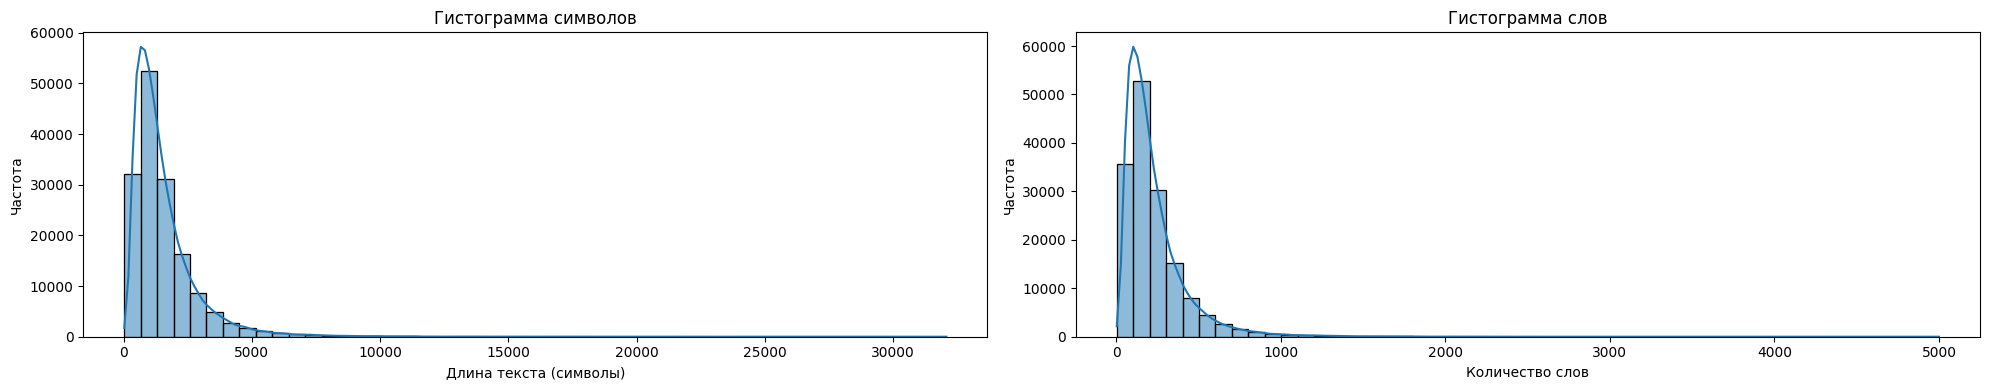

In [ ]:
# ГРАФИКИ
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 4))

sns.histplot(data=df_sym_words, x=df_sym_words['len_symbol'], kde=True, bins=50, ax=axes[0])
axes[0].set_title('Гистограмма символов')
axes[0].set_xlabel('Длина текста (символы)')
axes[0].set_ylabel('Частота')

sns.histplot(data=df_sym_words, x=df_sym_words['count_words'], kde=True, bins=50, ax=axes[1])
axes[1].set_title('Гистограмма слов')
axes[1].set_xlabel('Количество слов')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

## 3. Найдите 10 самых частых:

### 3.1 10 самых частых слов:

In [ ]:
# С ПОМОЩЬЮ CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
corpus = df_sym_words['text'].values

In [ ]:
# Функция расчёта частот слов в корпусе
def get_top_word(corpus, stop_words=None, top=None):
  vectorizer = CountVectorizer(stop_words=stop_words)       # получаем разряжённую, sparse матрицу
  vector_words = vectorizer.fit_transform(corpus)
  word_count = np.array(vector_words.sum(axis=0)).flatten() # Суммирую частоты слов по всем отзывам (по столбцам матрицы)
  word_names = vectorizer.get_feature_names_out()           # Получаю список слов (в том же порядке, что и в матрице)
  df_word_freq = pd.DataFrame({
    'слово': word_names,
    'количество': word_count
}).sort_values('количество', ascending=False)
  return df_word_freq.head(top)

In [ ]:
df_fregs_word = get_top_word(corpus)

In [ ]:
# ТОП 10 СЛОВ
df_fregs_word.head(10)

,слово,количество
192005,не,852416
184634,на,707784
339466,что,640053
237425,по,372738
180654,мне,320956
85679,банка,275765
85670,банк,215209
155180,как,205679
204098,но,200416
133681,за,192847


### 3.2 10 самых слов без стоп-слов

In [ ]:
# C ПОМОЩЬЮ nltk stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
stop_words = list(stopwords.words('russian') + stopwords.words('english'))
stop_words[:10]

['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со']

In [ ]:
df_fregs_word_stop_words = get_top_word(corpus=corpus, stop_words=stop_words)

In [ ]:
# ТОП 10 СЛОВ БЕЗ стоп-слов
df_fregs_word_stop_words.head(10)

,слово,количество
85557,банка,275765
85548,банк,215209
344931,это,183365
121806,деньги,131197
156643,карту,105824
156658,карты,101814
166119,кредит,81116
121798,день,76546
85595,банке,72085
144870,заявление,70422


### 3.3 ТОП 10 ЛЕММ

In [ ]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 20.1 MB/s eta 0:00:00


In [ ]:
from string import  punctuation
from collections import Counter
import pymorphy3
from nltk import word_tokenize
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
# Инициализируем морфоанализатор
morph = pymorphy3.MorphAnalyzer()

In [ ]:
# Этап ТОКЕНИЗАЦИИ
tokens = [token for tweet in df.text for token in word_tokenize(tweet) if token not in punctuation]
print(f'Всего токенов: {len(tokens)}')
tokens[:5]

Всего токенов: 36766261


['Добрый', 'день', 'Я', 'не', 'являюсь']

In [ ]:
# Пример форманализа, получение леммы
world = 'банка'
morph.parse(world)[0].score, morph.parse(world)[0].tag.POS, morph.parse(world)[0].normal_form

(0.954545, 'NOUN', 'банк')

In [ ]:
# формируем списки ЛЕММ и ЛЕММ-существительные
list_lemm = []
list_noun = []
for token in tokens:
  parsed = morph.parse(token)[0]
  lemma = parsed.normal_form
  list_lemm.append(lemma)
  if parsed.tag.POS == 'NOUN' and parsed.score > 0.5: # Добавляем существительные
    list_noun.append(lemma)

list_lemm[:5]
list_noun[:5]

['день', 'клиент', 'банк', 'поручитель', 'договор']

In [ ]:
lemm_count_dict = Counter(list_lemm)
lemm_noun_dict = Counter(list_noun)

In [ ]:
df_lemm = pd.DataFrame(lemm_count_dict.items(), columns=['лемма', 'частота']).sort_values(by='частота', ascending=False)

In [ ]:
print(df_lemm['частота'].sum())
df_lemm.head(10)

36766261


,лемма,частота,ранг
55,в,1341688,1
2,я,1118795,2
7,и,1054485,3
3,не,851742,4
39,на,704396,5
77,что,644916,6
6,банк,624272,7
20,с,514990,8
82,быть,420834,9
9,по,365188,10


In [ ]:
# Второй вариант
lemm_count_dict.most_common(10)

[('в', 1341688),
 ('я', 1118795),
 ('и', 1054485),
 ('не', 851742),
 ('на', 704396),
 ('что', 644916),
 ('банк', 624272),
 ('с', 514990),
 ('быть', 420834),
 ('по', 365188)]

### ТОП 10 существительных

In [ ]:
df_lemm_noun = pd.DataFrame(lemm_noun_dict.items(), columns=['существительное', 'частота']).sort_values(by='частота', ascending=False)

In [ ]:
# ТОП 10 Существительных
df_lemm_noun.head(10)

,существительное,частота,ранг
2,банк,624272,1
49,карта,331815,2
94,деньга,178332,3
0,день,172471,4
24,кредит,154865,5
65,отделение,143614,6
150,сотрудник,133662,7
1,клиент,130484,8
81,сумма,110914,9
10,год,103168,10


In [ ]:
# Второй вариант
# ТОП 10 Существительных
Counter(list_noun).most_common(10)

[('банк', 624272),
 ('карта', 331815),
 ('деньга', 178332),
 ('день', 172471),
 ('кредит', 154865),
 ('отделение', 143614),
 ('сотрудник', 133662),
 ('клиент', 130484),
 ('сумма', 110914),
 ('год', 103168)]

## 4. Постройте кривые Ципфа и Хипса

In [ ]:
#freg_token = Counter(tokens).most_common()

In [ ]:
#fregs_= [freg[1] for freg in sorted(freg_token[:20], key=lambda x: x[1], reverse=True)] # частоты токенов

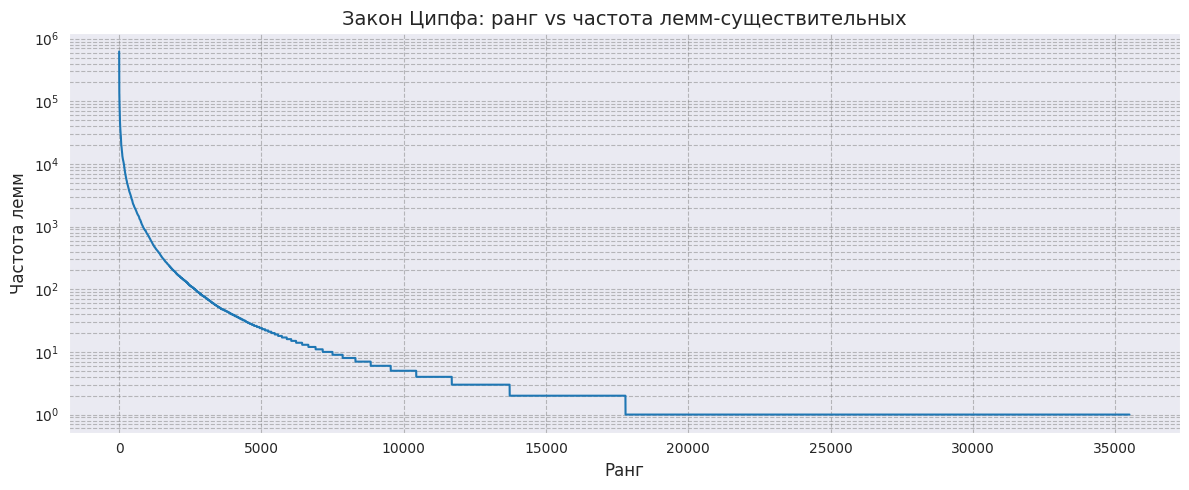

In [ ]:
# Добавление колонки 'ранг' в датафрейм
df_lemm_noun['ранг'] = range(1, len(df_lemm_noun) + 1)
sns.set_style('darkgrid')

plt.figure(figsize=(12, 5))
ax = sns.lineplot(data=df_lemm_noun, x='ранг', y='частота')

# Настройка оси (логарифмический масштаб!) # без лог маштаба кривая  резко падает и не показывает линейную зависимость
ax.set_yscale('log')

ax.set_xlabel('Ранг', fontsize=12)
ax.set_ylabel('Частота лемм', fontsize=12)

ax.set_title('Закон Ципфа: ранг vs частота лемм-существительных', fontsize=14)
ax.grid(True, which='both', ls='--', c='gray', alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:

# 1. Инициализация
cnt = Counter()  # счётчик уникальных токенов
n_words = []     # число уникальных слов на текущий момент
n_tokens = []    # общее число токенов на текущий момент
all_tokens = []  # накопительный список всех токенов (для последовательного роста)

# 2. Обработка документов по порядку
for index, row in tqdm(df_sym_words.iterrows(), total=len(df_sym_words), desc="Обработка документов"):
    # Токенизация текущего текста
    tokens = word_tokenize(row['text'])
    # Фильтрация: оставляем только слова (без пунктуации)
    filtered_tokens = [token for token in tokens if token not in punctuation]

    # Добавление токенов в общий поток
    all_tokens.extend(filtered_tokens)

    # Обновление счётчика уникальных слов
    cnt.update(filtered_tokens)

    # Фиксация текущего состояния
    n_words.append(len(cnt))           # число уникальных слов
    n_tokens.append(len(all_tokens))   # общее число токенов

Обработка документов: 100%|██████████| 153499/153499 [06:14<00:00, 409.48it/s]


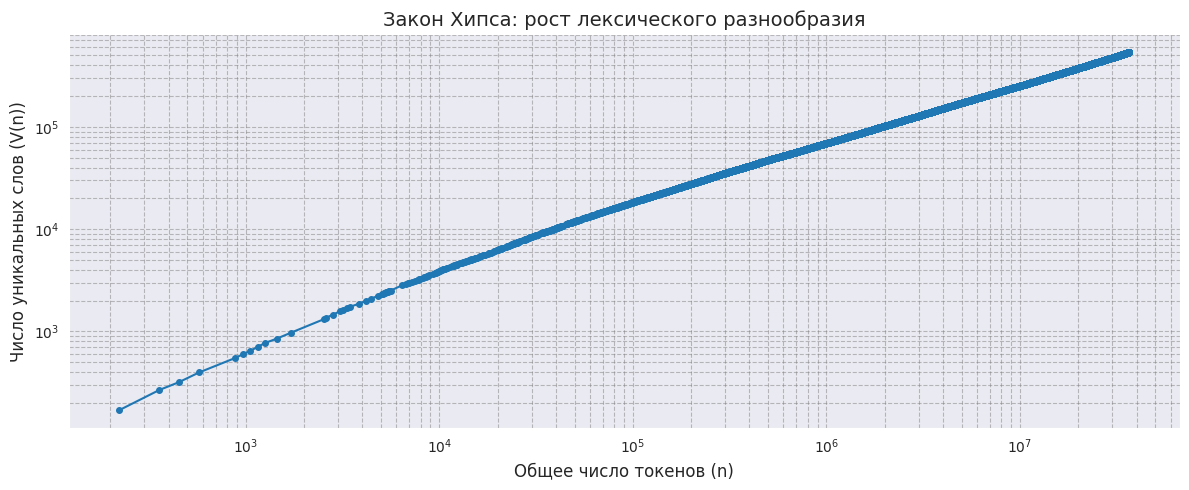

In [ ]:
# 3. Построение графика Хипса (в логарифмическом масштабе)
sns.set_style('darkgrid')
plt.figure(figsize=(12, 5))
plt.plot(n_tokens, n_words, marker='o', linestyle='-', markersize=4)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Общее число токенов (n)', fontsize=12)
plt.ylabel('Число уникальных слов (V(n))', fontsize=12)
plt.title('Закон Хипса: рост лексического разнообразия', fontsize=14)
plt.grid(True, which='both', ls='--', c='gray', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Ответьте на следующие вопросы:
какое слово встречается чаще, “сотрудник” или “клиент”?

сколько раз встречается слова “мошенничество” и “доверие”?

In [ ]:
print(f'Cлово "сотрудник" встречается чаще чем слово "клиент"\nСлово "мошенничество" встречается - 3228\nСлово "доверие" встречается - 2098')
df_lemm_noun.loc[df_lemm_noun['существительное'].isin(['сотрудник','клиент', 'мошенничество', 'доверие'])]

Cлово "сотрудник" встречается чаще чем слово "клиент"
Слово "мошенничество" встречается - 3228
Слово "доверие" встречается - 2098


,существительное,частота,ранг
150,сотрудник,133662,7
1,клиент,130484,8
772,мошенничество,3228,398
521,доверие,2098,527


## 6. В поле “rating_grade” записана оценка отзыва по шкале от 1 до 5. Используйте меру $tf-idf$, для того, чтобы найти ключевые слова и биграмы для положительных отзывов (с оценкой 5) и отрицательных отзывов (с оценкой 1)



In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
df_sym_words.head(1)

,text,len_symbol,count_words,rating_grade
0,Добрый день! Я не являюсь клиентом банка и пор...,1523,213,NaN


In [ ]:
# Код с целью исключить стоп - слова
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
stop_words = list(stopwords.words('russian') + stopwords.words('english'))
stop_words[:10]

['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со']

In [ ]:
# Положительные отзывы (оценка 5)
positive_reviews = df_sym_words[df_sym_words['rating_grade'] == 5]['text'].dropna()

# Отрицательные отзывы (оценка 1)
negative_reviews = df_sym_words[df_sym_words['rating_grade'] == 1]['text'].dropna()

In [ ]:
# Функция для извлечения ключевых слов с помощью TF-IDF
def get_top_tfidf_features(corpus, n_features=20, ngram_range=(1, 1)):
    tfidf = TfidfVectorizer(ngram_range=ngram_range,
                           stop_words=stop_words,
                           max_features=5000)
    # Обучение
    tfidf.fit(corpus)

    # Матрица TF-IDF для документов
    tfidf_matrix = tfidf.transform(corpus)

    # Вычисление среднего значения TF-IDF для каждого признака
    feature_names = tfidf.get_feature_names_out()
    tfidf_mean = np.array(tfidf_matrix.mean(axis=0)).flatten()

    # Сортировка признаков по среднему значению TF-IDF
    indices = tfidf_mean.argsort()[::-1]
    top_features = [(feature_names[i], tfidf_mean[i]) for i in indices[:n_features]]

    return top_features

In [ ]:
# Ключевые слова (униграммы)
positive_unigrams = get_top_tfidf_features(positive_reviews, n_features=20, ngram_range=(1, 1))
negative_unigrams = get_top_tfidf_features(negative_reviews, n_features=20, ngram_range=(1, 1))

# Ключевые биграммы
positive_bigrams = get_top_tfidf_features(positive_reviews, n_features=20, ngram_range=(2, 2))
negative_bigrams = get_top_tfidf_features(negative_reviews, n_features=20, ngram_range=(2, 2))

### Визуализации результатов

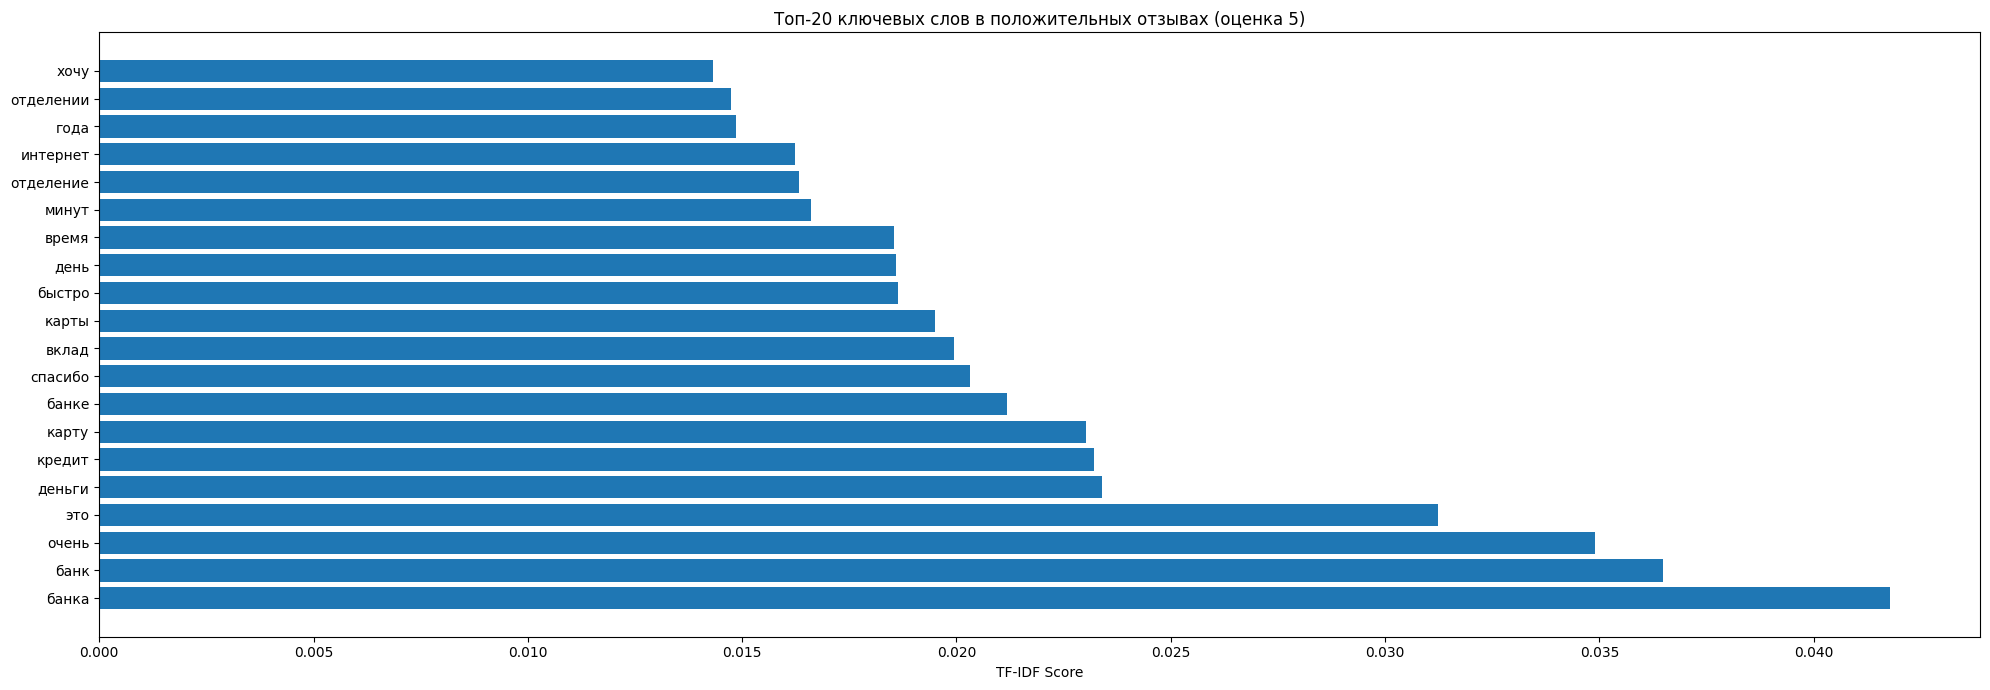

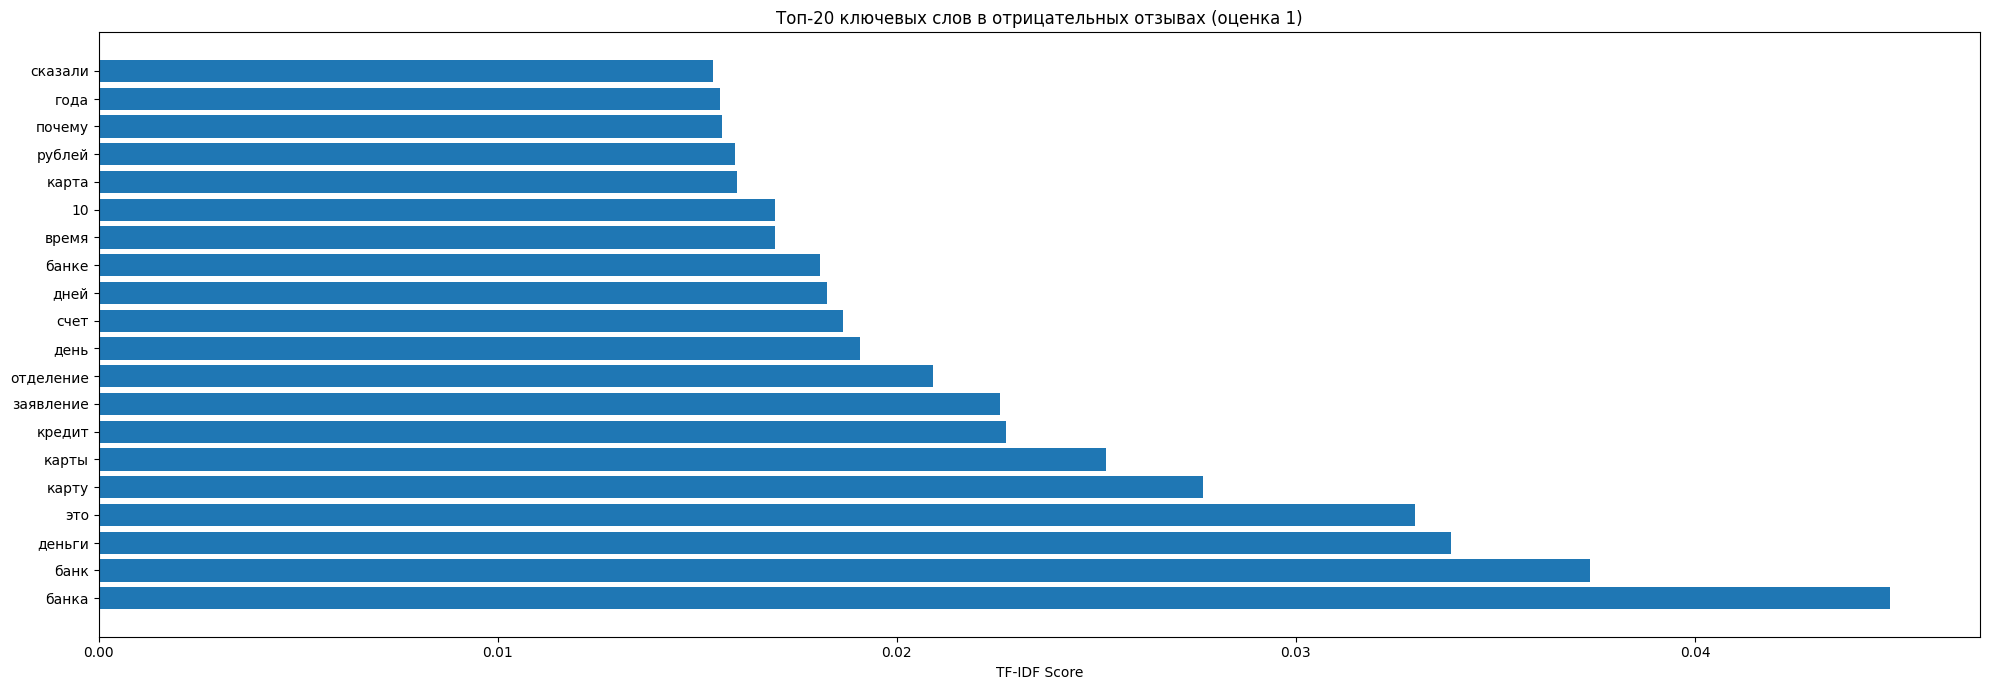

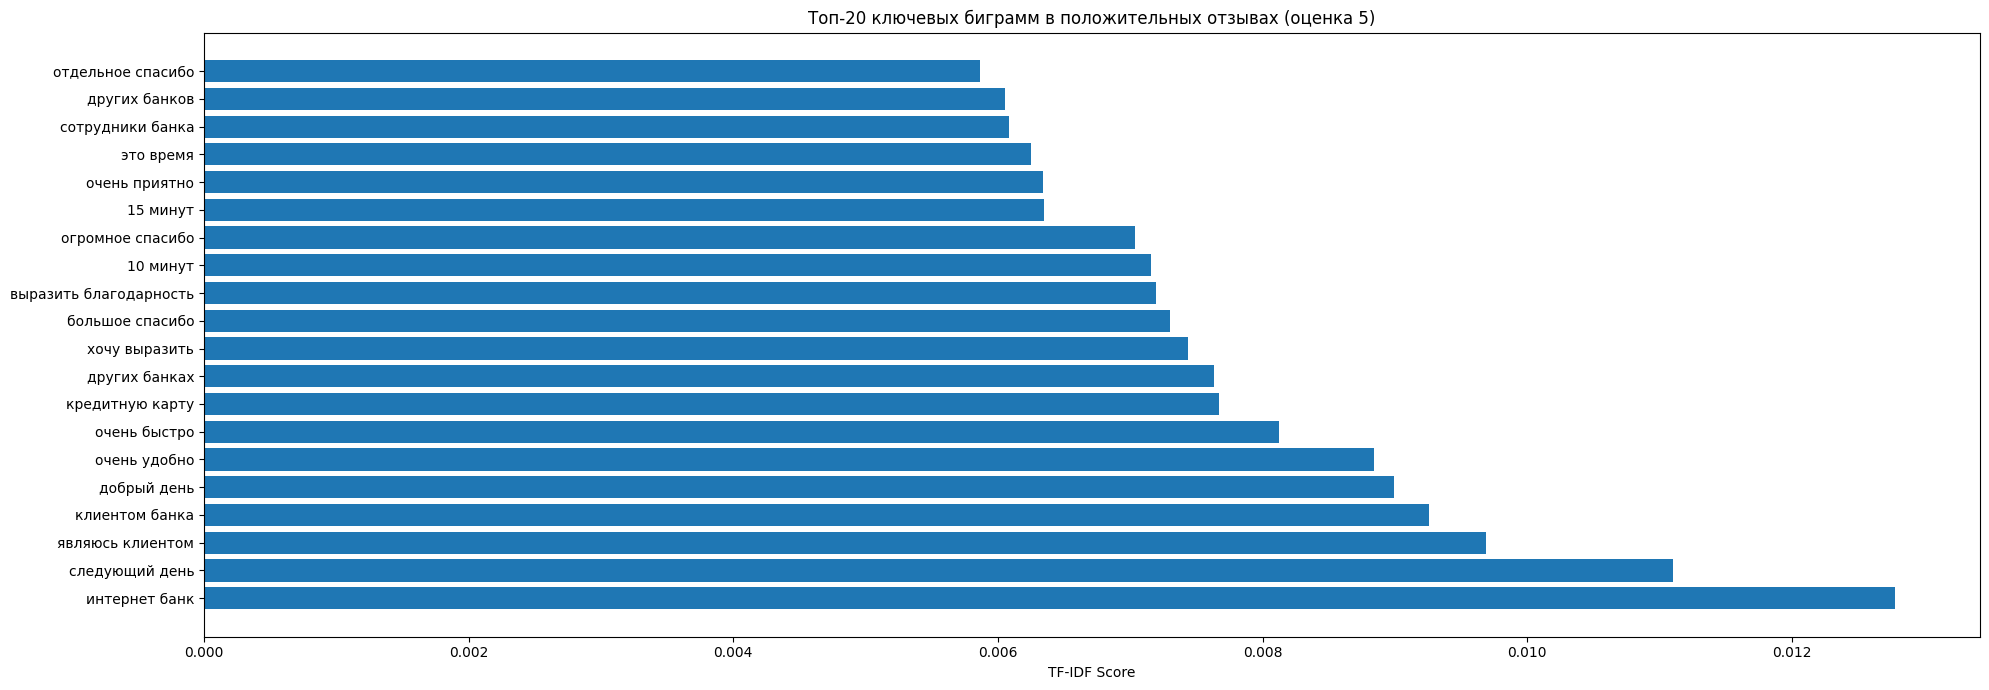

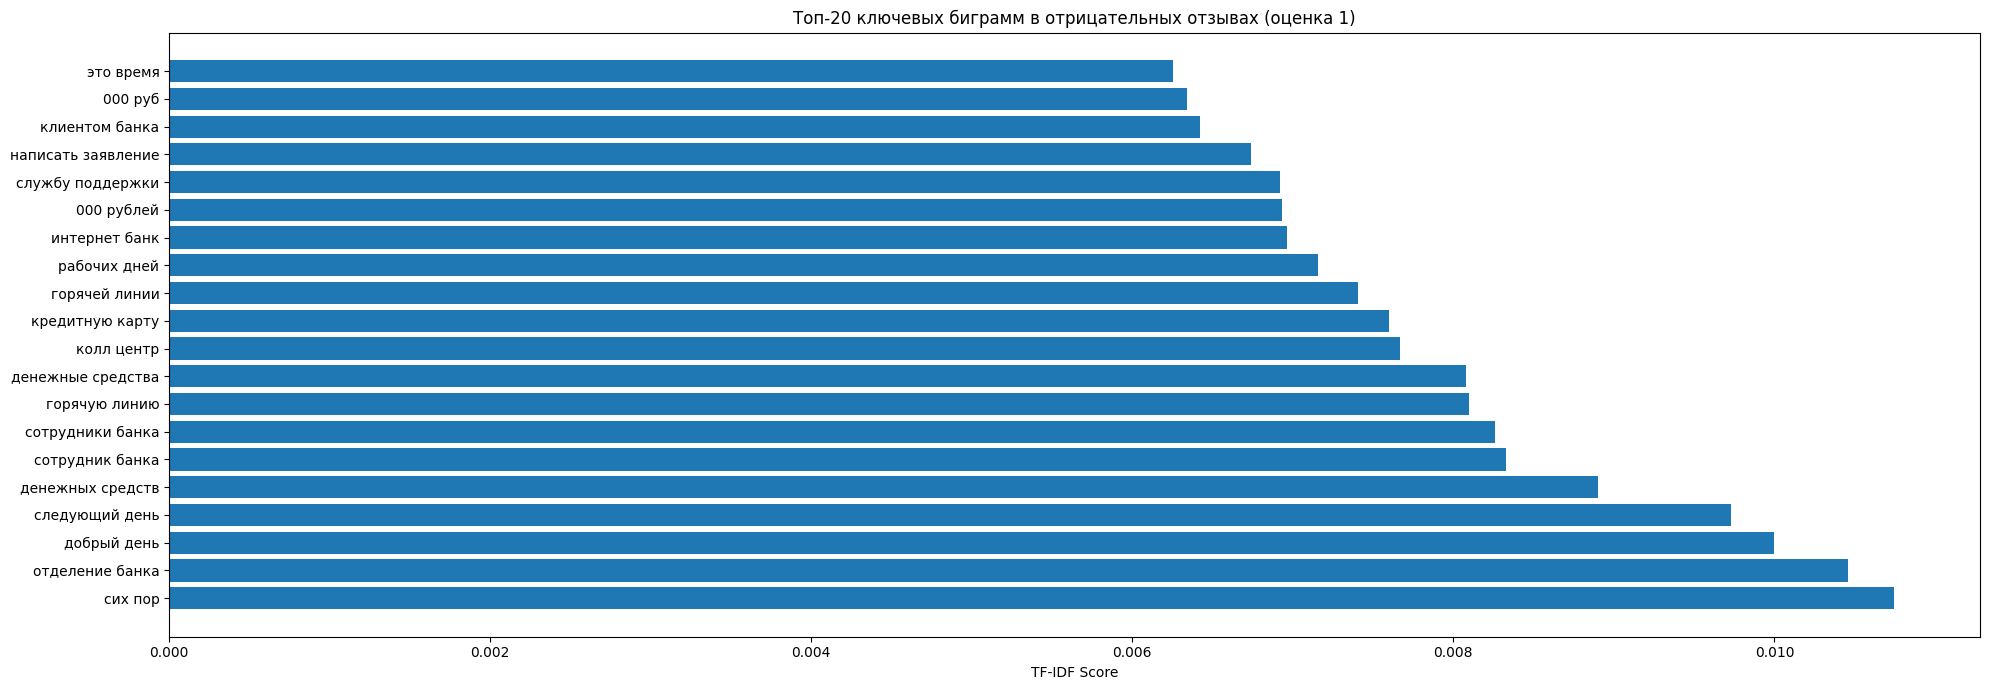

In [ ]:
# Функция для визуализации результатов
def plot_top_features(features, title):
    words = [word for word, score in features]
    scores = [score for word, score in features]

    plt.figure(figsize=(20, 7))
    plt.barh(range(len(words)), scores, align='center')
    plt.yticks(range(len(words)), words)
    plt.title(title)
    plt.xlabel('TF-IDF Score')
    plt.tight_layout()
    plt.show()

# Визуализация результатов
plot_top_features(positive_unigrams, 'Топ-20 ключевых слов в положительных отзывах (оценка 5)')
plot_top_features(negative_unigrams, 'Топ-20 ключевых слов в отрицательных отзывах (оценка 1)')
plot_top_features(positive_bigrams, 'Топ-20 ключевых биграмм в положительных отзывах (оценка 5)')
plot_top_features(negative_bigrams, 'Топ-20 ключевых биграмм в отрицательных отзывах (оценка 1)')

### Результаты в текстовом формате

In [ ]:
# Вывод результатов в текстовом формате
print("Топ-20 ключевых слов в положительных отзывах (оценка 5):")
for word, score in positive_unigrams:
    print(f"{word}: {score:.4f}")

print("\nТоп-20 ключевых слов в отрицательных отзывах (оценка 1):")
for word, score in negative_unigrams:
    print(f"{word}: {score:.4f}")

print("\nТоп-20 ключевых биграмм в положительных отзывах (оценка 5):")
for bigram, score in positive_bigrams:
    print(f"{bigram}: {score:.4f}")

print("\nТоп-20 ключевых биграмм в отрицательных отзывах (оценка 1):")
for bigram, score in negative_bigrams:
    print(f"{bigram}: {score:.4f}")

Топ-20 ключевых слов в положительных отзывах (оценка 5):
банка: 0.0418
банк: 0.0365
очень: 0.0349
это: 0.0312
деньги: 0.0234
кредит: 0.0232
карту: 0.0230
банке: 0.0212
спасибо: 0.0203
вклад: 0.0200
карты: 0.0195
быстро: 0.0186
день: 0.0186
время: 0.0185
минут: 0.0166
отделение: 0.0163
интернет: 0.0162
года: 0.0149
отделении: 0.0147
хочу: 0.0143

Топ-20 ключевых слов в отрицательных отзывах (оценка 1):
банка: 0.0449
банк: 0.0374
деньги: 0.0339
это: 0.0330
карту: 0.0277
карты: 0.0252
кредит: 0.0227
заявление: 0.0226
отделение: 0.0209
день: 0.0191
счет: 0.0187
дней: 0.0182
банке: 0.0181
время: 0.0170
10: 0.0169
карта: 0.0160
рублей: 0.0159
почему: 0.0156
года: 0.0156
сказали: 0.0154

Топ-20 ключевых биграмм в положительных отзывах (оценка 5):
интернет банк: 0.0128
следующий день: 0.0111
являюсь клиентом: 0.0097
клиентом банка: 0.0093
добрый день: 0.0090
очень удобно: 0.0088
очень быстро: 0.0081
кредитную карту: 0.0077
других банках: 0.0076
хочу выразить: 0.0074
большое спасибо: 0.0073
выр

# ЧАСТЬ 2. Тематическое моделирование

## 1. Постройте несколько тематических моделей коллекции документов с разным числом тем. Приведите примеры понятных (интерпретируемых) тем.

In [ ]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 60.1 MB/s eta 0:00:00


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
from tqdm import tqdm
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
import pymorphy3
from gensim import corpora, models
import gensim

In [ ]:
df.head()

,city,rating_not_checked,title,num_comments,bank_license,author,bank_name,datetime,text,rating_grade
0,г. Москва,False,Жалоба,0,лицензия № 2562,uhnov1,Бинбанк,2015-06-08 12:50:54,Добрый день! Я не являюсь клиентом банка и пор...,NaN
1,г. Новосибирск,False,Не могу пользоваться услугой Сбербанк он-лайн,0,лицензия № 1481,Foryou,Сбербанк России,2015-06-08 11:09:57,Доброго дня! Являюсь держателем зарплатной кар...,NaN
2,г. Москва,False,Двойное списание за один товар.,1,лицензия № 2562,Vladimir84,Бинбанк,2015-06-05 20:14:28,Здравствуйте! Дублирую свое заявление от 03.0...,NaN
3,г. Ставрополь,False,Меняют проценты комиссии не предупредив и не ...,2,лицензия № 1481,643609,Сбербанк России,2015-06-05 13:51:01,Добрый день!! Я открыл расчетный счет в СберБа...,NaN
4,г. Челябинск,False,Верните денежные средства за страховку,1,лицензия № 2766,anfisa-2003,ОТП Банк,2015-06-05 10:58:12,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN


In [ ]:
# Датафрейм df с текстами отзывов в столбце 'text'
# df = pd.read_csv('bank_reviews.csv')

In [ ]:
# Загрузка необходимых ресурсов
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Случайная подвыборка 20 % данных
df_sample = df.sample(frac=0.2, random_state=1982)

In [ ]:
# Функция для предобработки текста
def preprocess_text(text):
    if isinstance(text, str):
        # Приведение к нижнему регистру
        text = text.lower()
        # Удаление чисел, специальных символов
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'[^\w\s]', '', text)
        # Токенизация
        tokens = word_tokenize(text)
        # Удаление стоп-слов
        russian_stopwords = stopwords.words('russian')
        # Улучшение чистоты тем, с целью акцента на содержательные различия.
        # сосредоточиться на более специфических терминах, которые действительно различают темы (например, "кредит, вклад, обслуживание").
        additional_stopwords = ['банк', 'банка', 'банки', 'банком', 'банке']
        russian_stopwords.extend(additional_stopwords)
        tokens = [token for token in tokens if token not in russian_stopwords and len(token) > 2]
        # Лемматизация
        morph = pymorphy3.MorphAnalyzer()
        lemmatized_tokens = [morph.parse(word)[0].normal_form for word in tokens]
        return lemmatized_tokens
    return []

In [ ]:
# Применение предобработки к текстам
tqdm.pandas() # Активация tqdm для pandas
texts = df_sample['text'].progress_apply(preprocess_text).tolist()
#texts = df_sample['text'].apply(preprocess_text).tolist() # код без отображения прогресс-бар во время обработки текстов

100%|██████████| 30700/30700 [1:12:52<00:00,  7.02it/s]


In [ ]:
texts.to_csv('preprocess_text', sep=',', encoding='utf-8')

In [ ]:
# Создание словаря и корпуса для gensim
dictionary = corpora.Dictionary(texts)
# Фильтрация слишком редких и слишком частых слов
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in texts]

### gensim

In [ ]:
# Построение модели LDA с 10 темами
lda_model_10 = gensim.models.ldamodel.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    passes=15
)

# Построение модели LDA с 15 темами
lda_model_15 = gensim.models.ldamodel.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=15,
    random_state=42,
    passes=15
)

# Построение модели LDA с 20 темами
lda_model_20 = gensim.models.ldamodel.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=20,
    random_state=42,
    passes=15
)

###Использование NMF (Non-negative Matrix Factorization) как альтернативной модели

In [ ]:
# Использование NMF (Non-negative Matrix Factorization) как альтернативной модели
# Преобразование корпуса в TF-IDF
tfidf = models.TfidfModel(corpus)
corpus_tfidf = tfidf[corpus]

# NMF модель с 10 темами
nmf_model_10 = models.Nmf(
    corpus=corpus_tfidf,
    id2word=dictionary,
    num_topics=10,
    random_state=42
)

### Разбор тем и выводы. Модель gensim

In [ ]:
# Вывод тем для LDA модели с 10 темами
print("LDA модель с 10 темами:")
for topic_id, topic in lda_model_10.print_topics(num_words=10):
    print(f"Тема {topic_id}: {topic}")

# Вывод тем для LDA модели с 15 темами
print("\nLDA модель с 15 темами:")
for topic_id, topic in lda_model_15.print_topics(num_words=10):
    print(f"Тема {topic_id}: {topic}")

# Вывод тем для NMF модели с 10 темами
print("\nNMF модель с 10 темами:")
for topic_id, topic in nmf_model_10.print_topics(num_words=10):
    print(f"Тема {topic_id}: {topic}")

LDA модель с 10 темами:
Тема 0: 0.026*"кредит" + 0.020*"заявка" + 0.016*"документ" + 0.012*"сотрудник" + 0.012*"очень" + 0.010*"менеджер" + 0.009*"вопрос" + 0.009*"решение" + 0.008*"кредитный" + 0.008*"клиент"
Тема 1: 0.029*"телефон" + 0.028*"номер" + 0.025*"звонок" + 0.023*"звонить" + 0.017*"ваш" + 0.014*"сотрудник" + 0.013*"мой" + 0.011*"оператор" + 0.010*"вопрос" + 0.010*"информация"
Тема 2: 0.098*"карта" + 0.020*"отделение" + 0.019*"заявление" + 0.012*"сказать" + 0.011*"мой" + 0.010*"получить" + 0.009*"позвонить" + 0.008*"прийти" + 0.008*"написать" + 0.008*"сбербанк"
Тема 3: 0.026*"карта" + 0.013*"клиент" + 0.010*"счёт" + 0.008*"год" + 0.008*"обслуживание" + 0.008*"очень" + 0.008*"услуга" + 0.007*"банк" + 0.007*"комиссия" + 0.007*"пользоваться"
Тема 4: 0.065*"деньга" + 0.033*"банкомат" + 0.031*"счёт" + 0.017*"сумма" + 0.017*"сбербанк" + 0.015*"операция" + 0.015*"средство" + 0.014*"перевод" + 0.011*"рубль" + 0.011*"платёж"
Тема 5: 0.054*"кредит" + 0.033*"сумма" + 0.028*"платёж" + 0.

In [ ]:
# Поиск тем с упоминаниями конкретных банков
bank_names = ['сбербанк', 'втб', 'альфабанк', 'россельхозбанк', 'тинькофф', 'газпромбанк', 'райффайзенбанк']

print("\nТемы LDA-10 с упоминаниями конкретных банков:")
for bank in bank_names:
    if bank in dictionary.token2id:
        bank_id = dictionary.token2id[bank]
        for topic_id, topic_terms in enumerate(lda_model_10.get_topics()):
            if topic_terms[bank_id] > 0.01:  # Если вероятность слова в теме достаточно высока
                print(f"Банк '{bank}' упоминается в теме {topic_id} с вероятностью {topic_terms[bank_id]:.4f}")
                # Можно также вывести топ-слова этой темы
                print(f"Топ слова темы {topic_id}: {lda_model_10.show_topic(topic_id, topn=10)}")
                print()


Темы LDA-10 с упоминаниями конкретных банков:
Банк 'сбербанк' упоминается в теме 4 с вероятностью 0.0169
Топ слова темы 4: [('деньга', np.float32(0.064596295)), ('банкомат', np.float32(0.03329028)), ('счёт', np.float32(0.030762667)), ('сумма', np.float32(0.017288575)), ('сбербанк', np.float32(0.01694532)), ('операция', np.float32(0.015254939)), ('средство', np.float32(0.014876996)), ('перевод', np.float32(0.0136381425)), ('рубль', np.float32(0.011164671)), ('платёж', np.float32(0.010785495))]



In [ ]:
# Анализ документов по темам
def get_document_topics(lda_model, text):
    bow = dictionary.doc2bow(preprocess_text(text))
    return lda_model[bow]

In [ ]:
# Пример документа для каждого банка
for bank in bank_names:
    # Фильтрация документов, где упоминается банк
    bank_docs = df[df['text'].str.contains(bank, case=False, na=False)]
    if not bank_docs.empty:
        example_doc = bank_docs.iloc[0]['text']
        print(f"\nПример отзыва о {bank}:")
        print(example_doc[:200] + "..." if len(example_doc) > 200 else example_doc)
        print("Распределение тем в этом документе (LDA-10):")
        doc_topics = get_document_topics(lda_model_10, example_doc)
        for topic_id, prob in sorted(doc_topics, key=lambda x: x[1], reverse=True):
            if prob > 0.1:  # Показываем только темы с вероятностью выше 0.1
                print(f"Тема {topic_id} (вероятность {prob:.2f}): {lda_model_10.print_topic(topic_id, topn=7)}")



Пример отзыва о сбербанк:
Доброго дня! Являюсь держателем зарплатной карты , выданной Сбербанком России. В 2008 году сменила фамилию, предоставила в банк  документы (копию нового паспорта, свидетельства о браке), мне перевыпус...
Распределение тем в этом документе (LDA-10):
Тема 2 (вероятность 0.47): 0.098*"карта" + 0.020*"отделение" + 0.019*"заявление" + 0.012*"сказать" + 0.011*"мой" + 0.010*"получить" + 0.009*"позвонить"
Тема 7 (вероятность 0.21): 0.045*"договор" + 0.027*"документ" + 0.016*"счёт" + 0.010*"условие" + 0.010*"паспорт" + 0.009*"получить" + 0.008*"дать"
Тема 1 (вероятность 0.18): 0.029*"телефон" + 0.028*"номер" + 0.025*"звонок" + 0.023*"звонить" + 0.017*"ваш" + 0.014*"сотрудник" + 0.013*"мой"
Тема 0 (вероятность 0.12): 0.026*"кредит" + 0.020*"заявка" + 0.016*"документ" + 0.012*"сотрудник" + 0.012*"очень" + 0.010*"менеджер" + 0.009*"вопрос"

Пример отзыва о втб:
Добрый день! Являюсь заемщиком в Банке ВТБ 24. Более года назад взяла кредит на 1 млн. руб, платила исправно до

# ЧАСТЬ 3. Классификация текстов

In [ ]:
# Для удобства некоторые библиотеки импортирую повторно
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

## 1. Подготовка данных для бинарной классификации

In [ ]:
df.head(1)

,city,rating_not_checked,title,num_comments,bank_license,author,bank_name,datetime,text,rating_grade
0,г. Москва,False,Жалоба,0,лицензия № 2562,uhnov1,Бинбанк,2015-06-08 12:50:54,Добрый день! Я не являюсь клиентом банка и пор...,NaN


In [ ]:
# Отбор только отзывов с оценками 1 и 5
binary_df = df[df['rating_grade'].isin([1, 5])].copy()

In [ ]:
# Преобразование оценки в бинарные метки (0 для оценки 1, 1 для оценки 5)
binary_df['label'] = (binary_df['rating_grade'] == 5).astype(int)

In [ ]:
binary_df.head(1)

,city,rating_not_checked,title,num_comments,bank_license,author,bank_name,datetime,text,rating_grade,label
19,г. Москва,False,Некомпетентность сотрудников банка,2,лицензия № 1481,agelun,Сбербанк России,2015-06-05 15:00:54,Открыт вклад и счет в USD. Плюс к этому есть з...,1.0,0


In [ ]:
# Баланс классов
print("Распределение классов:")
print(binary_df['label'].value_counts(normalize=True))

Распределение классов:
label
0    0.763076
1    0.236924
Name: proportion, dtype: float64


In [ ]:
# Разделяем данные на обучающую и тестовую выборки (80% на обучение, 20% на тест)
X_train, X_test, y_train, y_test = train_test_split(binary_df['text'], binary_df['label'],  test_size=0.2, random_state=1982, stratify=binary_df['label'])  # stratify - сохраняем пропорции классов

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер обучающей выборки: 49680
Размер тестовой выборки: 12420


In [ ]:
y_train.value_counts(normalize=True) # пропорции сохранены

,proportion
label,
0,0.763084
1,0.236916


## 2. Сравнение разных вариантов векторизации текста

In [ ]:
# Функция для оценки модели
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{model_name}:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-score: {f1:.4f}")
    return accuracy, f1

In [ ]:
# Список для хранения результатов
results = []

In [ ]:
# 1. Классификация с использованием униграмм
unigram_model = Pipeline([
    ('vect', CountVectorizer(max_features=5000)),
    ('clf', LogisticRegression(random_state=1982, max_iter=500))
])
unigram_model.fit(X_train, y_train)
uni_acc, uni_f1 = evaluate_model(unigram_model, X_test, y_test, "Униграммы (отдельные слова)")
results.append(('Униграммы', uni_acc, uni_f1))

Униграммы (отдельные слова):
  Accuracy: 0.9570
  F1-score: 0.9095


In [ ]:
unigram_model

Pipeline(steps=[('vect', CountVectorizer(max_features=5000)),
                ('clf', LogisticRegression(max_iter=500, random_state=1982))])

In [ ]:
# 2. Классификация с использованием биграмм и униграмм
bigram_model = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1, 2), max_features=5000)),
    ('clf', LogisticRegression(random_state=1982, max_iter=500))
])
bigram_model.fit(X_train, y_train)
bi_acc, bi_f1 = evaluate_model(bigram_model, X_test, y_test, "Униграммы + биграммы")
results.append(('Биграммы', bi_acc, bi_f1))

Униграммы + биграммы:
  Accuracy: 0.9560
  F1-score: 0.9074


In [ ]:
# 3. Классификация с использованием триграмм, биграмм и униграмм
trigram_model = Pipeline([
    ('vect', CountVectorizer(ngram_range=(1, 3), max_features=5000)),
    ('clf', LogisticRegression(random_state=1982, max_iter=500))
])
trigram_model.fit(X_train, y_train)
tri_acc, tri_f1 = evaluate_model(trigram_model, X_test, y_test, "Униграммы + биграммы + триграммы")
results.append(('Триграммы', tri_acc, tri_f1))

Униграммы + биграммы + триграммы:
  Accuracy: 0.9552
  F1-score: 0.9057


In [ ]:
# 4. Классификация с использованием символьных n-грамм
char_model = Pipeline([
    ('vect', CountVectorizer(analyzer='char_wb', ngram_range=(3, 5), max_features=5000)),
    ('clf', LogisticRegression(random_state=1982, max_iter=1500))
])
char_model.fit(X_train, y_train)
char_acc, char_f1 = evaluate_model(char_model, X_test, y_test, "Символьные n-граммы")
results.append(('Символьные n-граммы', char_acc, char_f1))

Символьные n-граммы:
  Accuracy: 0.9522
  F1-score: 0.9001


## 3. Использование скрытых тем в качестве признаков

### Вариант 1: TF-IDF + SVD = LSA

In [ ]:
# Латентный семантический анализ (LSA)
# Tfidf  + сингулярное разложение матрицы (SVD). LSA без SVD невозможен.
lsa_model = Pipeline([
    ('vect', CountVectorizer(max_features=5000)),
    ('tfidf', TfidfTransformer()),
    ('svd', TruncatedSVD(n_components=100, random_state=1982)),
    ('clf', LogisticRegression(random_state=1982))
])
lsa_model.fit(X_train, y_train)
lsa_acc, lsa_f1 = evaluate_model(lsa_model, X_test, y_test, "TF-IDF + SVD (LSA)")
results.append(('LSA', lsa_acc, lsa_f1))

TF-IDF + SVD (LSA):
  Accuracy: 0.9534
  F1-score: 0.8968


### Вариант 2: Тематическая модель LDA

In [ ]:
# Тематическая модель
lda_model = Pipeline([
    ('vect', CountVectorizer(max_features=5000)),
    ('lda', LatentDirichletAllocation(n_components=50, random_state=42)),
    ('clf', LogisticRegression(random_state=42))
])
lda_model.fit(X_train, y_train)
lda_acc, lda_f1 = evaluate_model(lda_model, X_test, y_test, "LDA")
results.append(('LDA', lda_acc, lda_f1))

LDA:
  Accuracy: 0.9421
  F1-score: 0.8709


### Визуализация результатов

In [ ]:
# Визуализация результатов
print("\nСводка результатов:")
for name, acc, f1 in results:
    print(f"{name}: Accuracy = {acc:.4f}, F1 = {f1:.4f}")


Сводка результатов:
Униграммы: Accuracy = 0.9570, F1 = 0.9095
Биграммы: Accuracy = 0.9560, F1 = 0.9074
Триграммы: Accuracy = 0.9552, F1 = 0.9057
Символьные n-граммы: Accuracy = 0.9522, F1 = 0.9001
LSA: Accuracy = 0.9534, F1 = 0.8968
LDA: Accuracy = 0.9421, F1 = 0.8709


In [ ]:
results_df = pd.DataFrame(results, columns=['Модель', 'Accuracy', 'F1-score'])

In [ ]:
results_df

,Модель,Accuracy,F1-score
0,Униграммы,0.957005,0.909522
1,Биграммы,0.956039,0.907395
2,Триграммы,0.955153,0.905705
3,Символьные n-граммы,0.952174,0.900134
4,LSA,0.953382,0.896810
5,LDA,0.942110,0.870939
